  STEP 1 OF 2 — Upload slate_sales_transactions.csv


Saving slate_sales_transactions.csv to slate_sales_transactions (1).csv

  STEP 2 OF 2 — Upload slate_staffing.csv


Saving slate_staffing.csv to slate_staffing (1).csv

✓ Both files loaded.

  DATA INSPECTION
  transaction_id       date   time day_of_week day_type  \
0       TXN01000 2024-11-01  10:05      Friday  Weekend   
1       TXN01001 2024-11-01  13:26      Friday  Weekend   
2       TXN01002 2024-11-01  11:56      Friday  Weekend   
3       TXN01003 2024-11-01  10:22      Friday  Weekend   
4       TXN01004 2024-11-01  15:33      Friday  Weekend   

                             item_name         category  quantity  \
0                         Slate Omelet          Omelets         2   
1  Great Balls of Fire - Wagyu Sliders          Burgers         1   
2                     Nutella Pancakes  Savory Delights         2   
3                       Slate Pancakes  Savory Delights         1   
4            Slate Beef Hotdog - Basic     Slate Street         1   

   unit_price_aed  discount_pct  total_revenue_aed  
0              29             0               58.0  
1              39             0

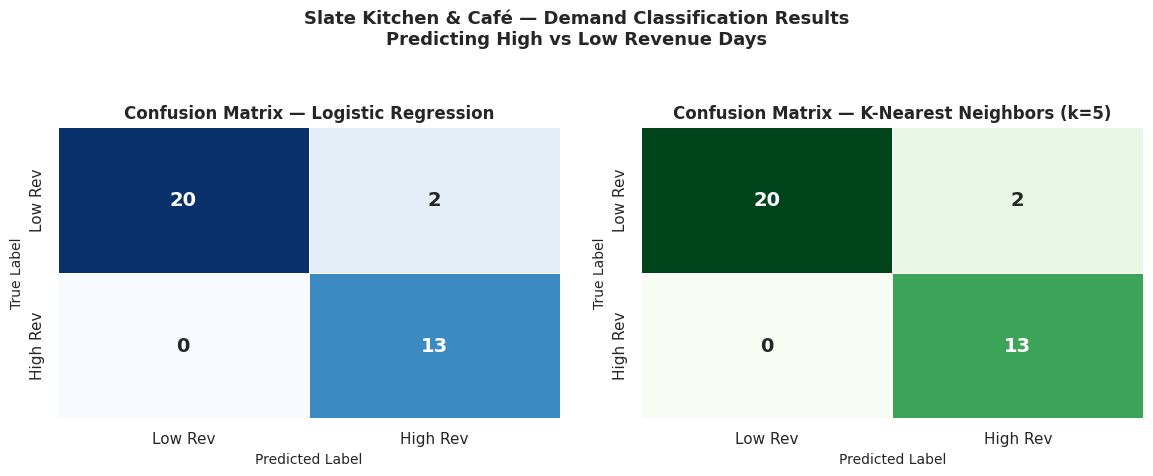

  Figure 1 saved → fig1_confusion_matrices.png


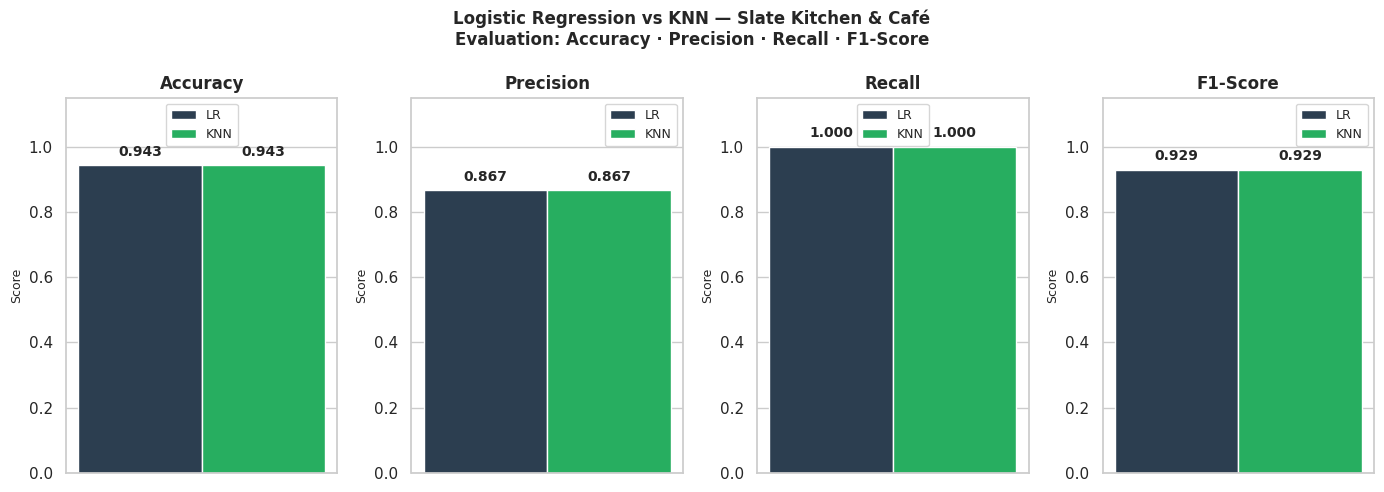

  Figure 2 saved → fig2_model_comparison.png


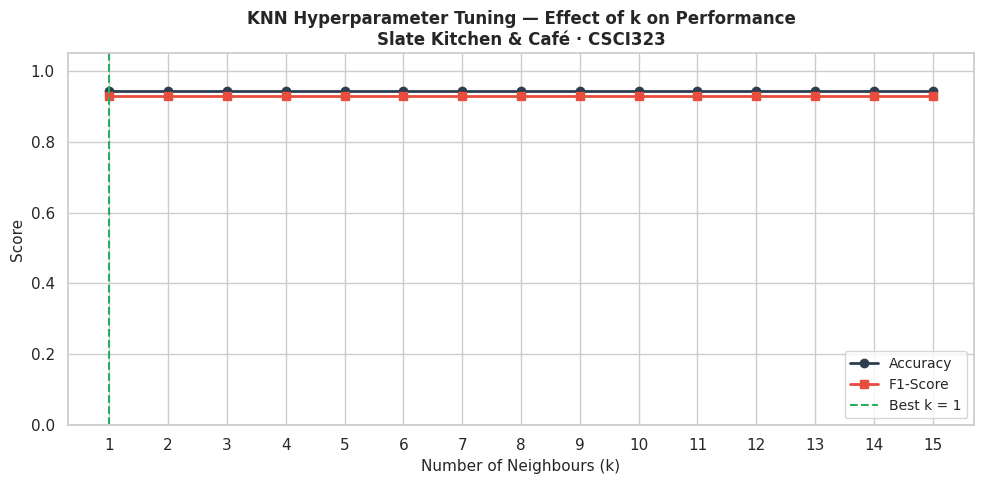

  Figure 3 saved → fig3_k_tuning.png


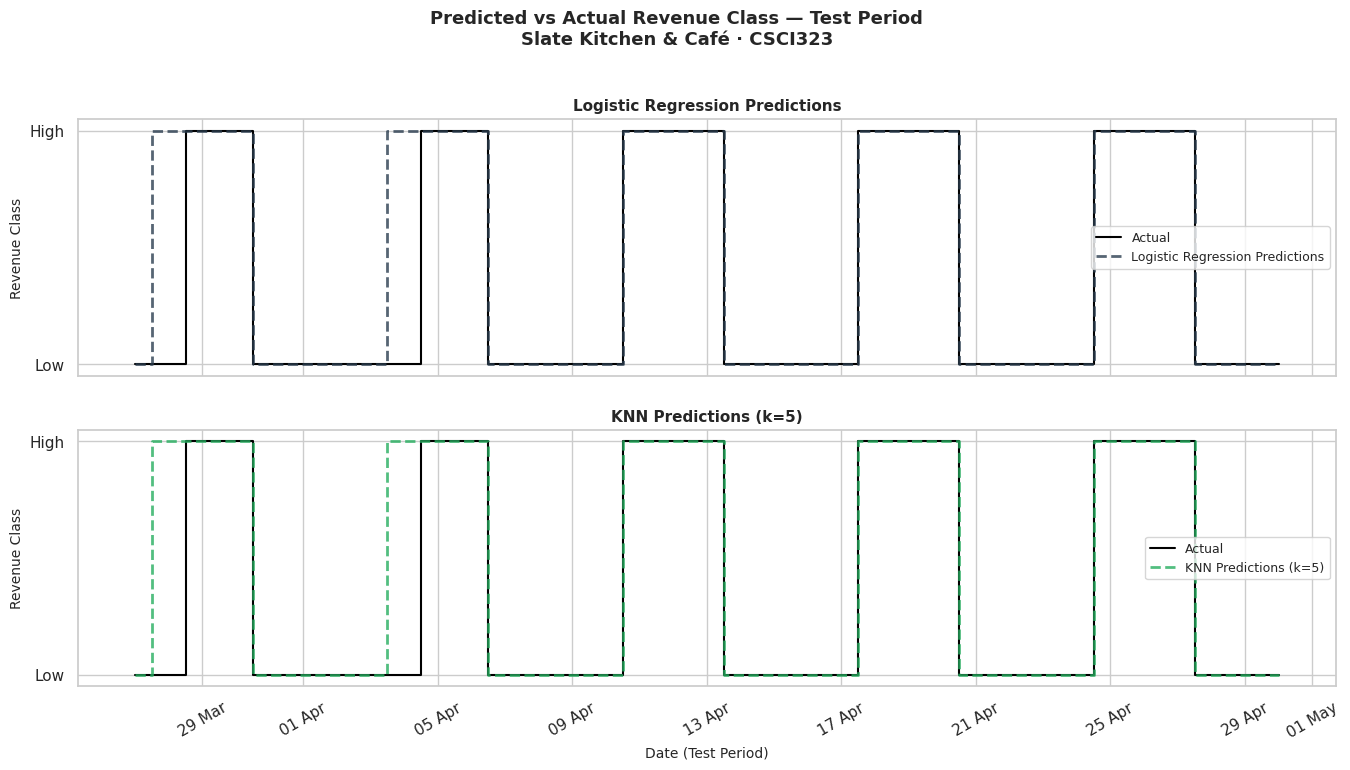

  Figure 4 saved → fig4_predictions_vs_actual.png


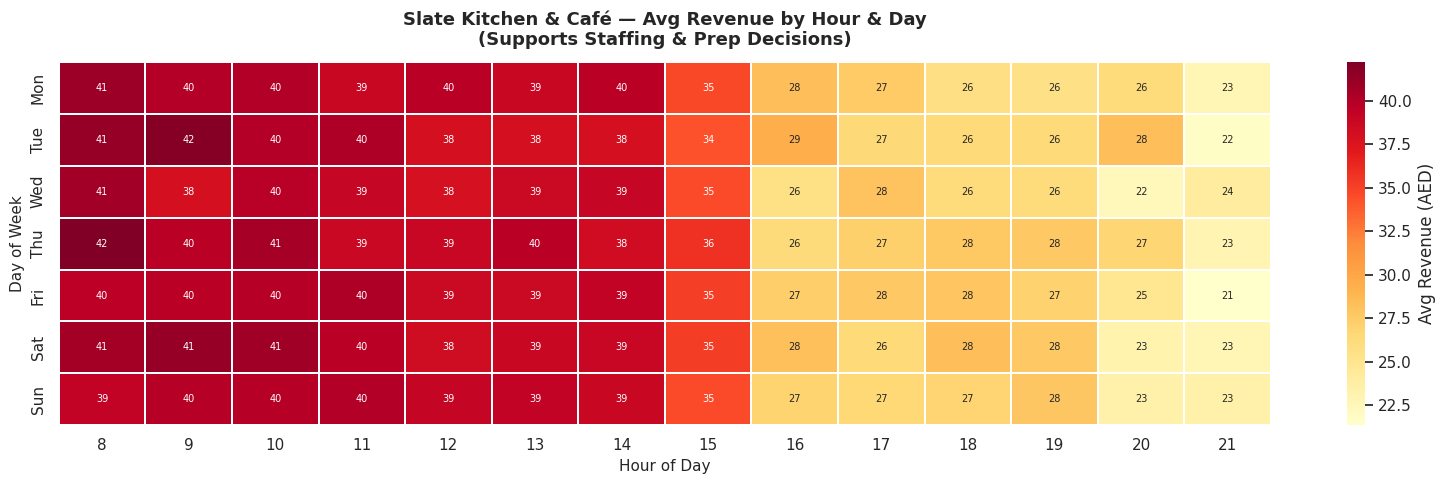

  Figure 5 saved → fig5_hourly_heatmap.png


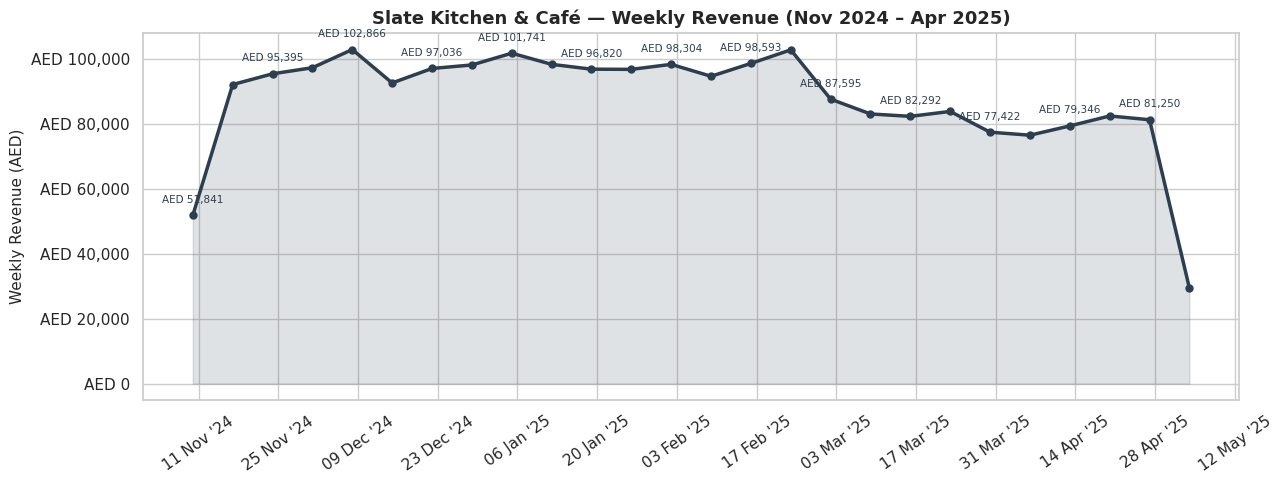

  Figure 6 saved → fig6_weekly_trend.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


  DEMAND FORECASTING — FINAL SUMMARY
  Training samples : 139 days
  Test samples     : 35 days
  Features used    : 18
  Revenue threshold: AED 12,438/day (median split)

  Logistic Regression:
    Accuracy  : 0.9429
    Precision : 0.8667
    Recall    : 1.0000
    F1-Score  : 0.9286

  KNN (k=5):
    Accuracy  : 0.9429
    Precision : 0.8667
    Recall    : 1.0000
    F1-Score  : 0.9286

  Best model (F1)  : Logistic Regression

  Outputs saved:
    slate_model_metrics.csv
    slate_forecast_output.csv
    fig1_confusion_matrices.png
    fig2_model_comparison.png
    fig3_k_tuning.png
    fig4_predictions_vs_actual.png
    fig5_hourly_heatmap.png
    fig6_weekly_trend.png


In [2]:
"""
Techniques used (from course lectures):
  - Data Preprocessing  (DataPreprocessing_Lecture)
  - Feature Engineering & One-Hot Encoding
  - Feature Scaling     (StandardScaler)
  - Logistic Regression (Week04_Presentation)
  - K-Nearest Neighbors (Week04_Presentation)
  - Train/Test Split    (80/20)
  - Evaluation: Accuracy, Precision, Recall, F1-Score
"""

# imports
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet",
                       "scikit-learn", "pandas", "numpy", "matplotlib", "seaborn"])

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection    import train_test_split
from sklearn.preprocessing      import StandardScaler, LabelEncoder
from sklearn.linear_model       import LogisticRegression
from sklearn.neighbors          import KNeighborsClassifier
from sklearn.metrics            import (accuracy_score, precision_score,
                                        recall_score, f1_score,
                                        confusion_matrix, classification_report)

sns.set_theme(style="whitegrid", font="DejaVu Sans")
PALETTE = ["#2C3E50", "#E74C3C", "#27AE60", "#F39C12", "#8E44AD"]

# File upload
try:
    from google.colab import files
    import io

    print("=" * 55)
    print("  STEP 1 OF 2 — Upload slate_sales_transactions.csv")
    print("=" * 55)
    up1 = files.upload()
    sales_file = list(up1.keys())[0]

    print("\n" + "=" * 55)
    print("  STEP 2 OF 2 — Upload slate_staffing.csv")
    print("=" * 55)
    up2 = files.upload()
    staff_file = list(up2.keys())[0]

    df_tx    = pd.read_csv(io.BytesIO(up1[sales_file]),  parse_dates=["date"])
    df_staff = pd.read_csv(io.BytesIO(up2[staff_file]),  parse_dates=["date"])
    print("\n✓ Both files loaded.\n")

except ModuleNotFoundError:
    df_tx    = pd.read_csv("slate_sales_transactions.csv",  parse_dates=["date"])
    df_staff = pd.read_csv("slate_staffing.csv",            parse_dates=["date"])
    print("✓ Files loaded from local directory.\n")

#Inspect data
print("=" * 55)
print("  DATA INSPECTION")
print("=" * 55)
print(df_tx.head())
print()
print(df_tx.info())
print()
print(df_tx.describe())
print(f"\n  Rows          : {len(df_tx):,}")
print(f"  Columns       : {df_tx.shape[1]}")
print(f"  Date range    : {df_tx['date'].min().date()} → {df_tx['date'].max().date()}")
print(f"  Missing values: {df_tx.isnull().sum().sum()}")
print(f"  Duplicates    : {df_tx.duplicated().sum()}")

# Aggregate daily
daily = df_tx.groupby("date").agg(
    total_revenue  = ("total_revenue_aed", "sum"),
    total_txn      = ("transaction_id",    "count"),
    total_items    = ("quantity",          "sum")
).reset_index()

covers = df_staff.groupby("date")["estimated_covers"].first().reset_index()
daily  = daily.merge(covers, on="date")

# Feature Engineering

print("\n" + "=" * 55)
print("  FEATURE ENGINEERING")
print("=" * 55)

daily = daily.sort_values("date").copy()

# Date-based features
daily["day_of_week"]  = daily["date"].dt.dayofweek      # 0=Mon … 6=Sun
daily["month"]        = daily["date"].dt.month
daily["day_of_month"] = daily["date"].dt.day
daily["is_weekend"]   = (daily["date"].dt.dayofweek >= 4).astype(int)
daily["is_friday"]    = (daily["date"].dt.dayofweek == 4).astype(int)
daily["peak_season"]  = daily["month"].isin([11,12,1,2]).astype(int)

# UAE public holidays
uae_holidays = pd.to_datetime([
    "2024-11-15","2024-12-02","2024-12-03","2024-12-25",
    "2025-01-01","2025-01-29","2025-03-30","2025-03-31","2025-04-01"
])
daily["is_holiday"] = daily["date"].isin(uae_holidays).astype(int)

# Lag features
daily["revenue_lag1"]     = daily["total_revenue"].shift(1)
daily["revenue_lag7"]     = daily["total_revenue"].shift(7)
daily["revenue_rolling7"] = daily["total_revenue"].shift(1).rolling(7).mean()
daily["covers_lag1"]      = daily["estimated_covers"].shift(1)

# Remove rows with NaN from lagging
daily = daily.dropna()
print(f"  Rows after lag feature creation: {len(daily)}")
print(f"  Duplicates removed             : {daily.duplicated().sum()}")

# Define classification target
# HIGH (1) = above median    LOW (0) = below median

median_rev = daily["total_revenue"].median()
daily["busy_day"] = (daily["total_revenue"] >= median_rev).astype(int)

print(f"\n  Revenue threshold (median) : AED {median_rev:,.0f}")
print(f"  High-revenue days (class 1): {daily['busy_day'].sum()}")
print(f"  Low-revenue days  (class 0): {(daily['busy_day']==0).sum()}")
print(f"  Class balance               : "
      f"{daily['busy_day'].mean()*100:.1f}% high / "
      f"{(1-daily['busy_day'].mean())*100:.1f}% low")

#One-Hot Encode day name (nominal categorical)
daily["day_name"] = daily["date"].dt.day_name()
daily = pd.get_dummies(daily, columns=["day_name"], drop_first=False)
print(f"\n  Columns after one-hot encoding day name: {daily.shape[1]}")

# Prepare feature matrix and target
FEATURES = [
    "day_of_week", "month", "day_of_month",
    "is_weekend", "is_friday", "peak_season", "is_holiday",
    "revenue_lag1", "revenue_lag7", "revenue_rolling7", "covers_lag1",
    "day_name_Friday", "day_name_Monday", "day_name_Saturday",
    "day_name_Sunday", "day_name_Thursday", "day_name_Tuesday", "day_name_Wednesday"
]
# Keep only columns that exist (in case some days are missing)
FEATURES = [f for f in FEATURES if f in daily.columns]

X = daily[FEATURES]
y = daily["busy_day"]

print(f"\n  Feature matrix shape: {X.shape}")
print(f"  Target distribution : {y.value_counts().to_dict()}")

# Train

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=False
)

print("\n" + "=" * 55)
print("  TRAIN / TEST SPLIT")
print("=" * 55)
print(f"  Training set : {X_train.shape[0]} samples  "
      f"({y_train.mean()*100:.1f}% high-revenue days)")
print(f"  Test set     : {X_test.shape[0]} samples  "
      f"({y_test.mean()*100:.1f}% high-revenue days)")

#Feature Scaling
# StandardScaler: mean=0, std=1.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform only on test

print("\n  StandardScaler applied.")
print(f"  X_train mean (post-scale): {X_train_scaled.mean():.6f}  "
      f"std: {X_train_scaled.std():.6f}")
print(f"  X_test  mean (post-scale): {X_test_scaled.mean():.4f}  "
      f"std: {X_test_scaled.std():.4f}")

#Logistic Regression
print("\n" + "=" * 55)
print("  LOGISTIC REGRESSION — TRAINING")
print("=" * 55)

lr_model = LogisticRegression(random_state=42, solver="liblinear")
lr_model.fit(X_train_scaled, y_train)
y_pred_lr = lr_model.predict(X_test_scaled)

acc_lr  = accuracy_score(y_test,  y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr  = recall_score(y_test,    y_pred_lr)
f1_lr   = f1_score(y_test,        y_pred_lr)
cm_lr   = confusion_matrix(y_test, y_pred_lr)

print(f"  Accuracy  : {acc_lr:.4f}")
print(f"  Precision : {prec_lr:.4f}")
print(f"  Recall    : {rec_lr:.4f}")
print(f"  F1-Score  : {f1_lr:.4f}")
print(f"\n  Classification Report:\n")
print(classification_report(y_test, y_pred_lr,
                             target_names=["Low Revenue", "High Revenue"]))

#K-Nearest Neighbors
print("=" * 55)
print("  K-NEAREST NEIGHBORS — TRAINING")
print("=" * 55)

knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_model.fit(X_train_scaled, y_train)   # KNN stores all training points
y_pred_knn = knn_model.predict(X_test_scaled)

acc_knn  = accuracy_score(y_test,  y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
rec_knn  = recall_score(y_test,    y_pred_knn)
f1_knn   = f1_score(y_test,        y_pred_knn)
cm_knn   = confusion_matrix(y_test, y_pred_knn)

print(f"  Accuracy  : {acc_knn:.4f}")
print(f"  Precision : {prec_knn:.4f}")
print(f"  Recall    : {rec_knn:.4f}")
print(f"  F1-Score  : {f1_knn:.4f}")
print(f"\n  Classification Report:\n")
print(classification_report(y_test, y_pred_knn,
                             target_names=["Low Revenue", "High Revenue"]))

# Results Comparison
print("=" * 55)
print("  MODEL COMPARISON — Logistic Regression vs KNN")
print("=" * 55)
print(f"  {'Metric':<14} {'LR':>10} {'KNN':>10} {'Winner':>10}")
print(f"  {'-'*46}")
for metric, lr_v, knn_v in [
    ("Accuracy",  acc_lr,  acc_knn),
    ("Precision", prec_lr, prec_knn),
    ("Recall",    rec_lr,  rec_knn),
    ("F1-Score",  f1_lr,   f1_knn),
]:
    winner = "LR ✓" if lr_v >= knn_v else "KNN ✓"
    print(f"  {metric:<14} {lr_v:>10.4f} {knn_v:>10.4f} {winner:>10}")

# K tuning for KNN
print("\n  K-value tuning (k=1 to 15):")
k_scores = []
for k in range(1, 16):
    m = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    m.fit(X_train_scaled, y_train)
    k_scores.append({
        "k": k,
        "accuracy": accuracy_score(y_test, m.predict(X_test_scaled)),
        "f1":       f1_score(y_test, m.predict(X_test_scaled))
    })
k_df = pd.DataFrame(k_scores)
best_k = k_df.loc[k_df["f1"].idxmax(), "k"]
print(f"  Best k (by F1): {int(best_k)}")

#14. Figures
# Fig 1 - Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, cm, title, color in zip(
    axes,
    [cm_lr, cm_knn],
    ["Logistic Regression", "K-Nearest Neighbors (k=5)"],
    ["Blues", "Greens"]
):
    sns.heatmap(cm, annot=True, fmt="d", cmap=color, ax=ax,
                xticklabels=["Low Rev", "High Rev"],
                yticklabels=["Low Rev", "High Rev"],
                linewidths=0.5, cbar=False,
                annot_kws={"size": 14, "weight": "bold"})
    ax.set_title(f"Confusion Matrix — {title}",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.set_ylabel("True Label", fontsize=10)
fig.suptitle("Slate Kitchen & Café — Demand Classification Results\n"
             "Predicting High vs Low Revenue Days",
             fontsize=13, fontweight="bold")
plt.tight_layout(pad=2)
plt.savefig("fig1_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Figure 1 saved → fig1_confusion_matrices.png")

# Fig 2 — Model Comparison Bar Chart
fig, axes = plt.subplots(1, 4, figsize=(14, 5))
metrics_list   = ["Accuracy", "Precision", "Recall", "F1-Score"]
lr_scores  = [acc_lr,  prec_lr, rec_lr,  f1_lr]
knn_scores = [acc_knn, prec_knn, rec_knn, f1_knn]
x = np.arange(1)
width = 0.3

for i, (ax, metric, lr_v, knn_v) in enumerate(
        zip(axes, metrics_list, lr_scores, knn_scores)):
    bars_lr  = ax.bar(x - width/2, lr_v,  width, label="LR",
                      color=PALETTE[0], edgecolor="white")
    bars_knn = ax.bar(x + width/2, knn_v, width, label="KNN",
                      color=PALETTE[2], edgecolor="white")
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.set_xticks([])
    ax.set_ylabel("Score", fontsize=9)
    ax.legend(fontsize=9)
    winner_color = PALETTE[0] if lr_v >= knn_v else PALETTE[2]
    for bar in [bars_lr[0], bars_knn[0]]:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f"{bar.get_height():.3f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold")
fig.suptitle("Logistic Regression vs KNN — Slate Kitchen & Café\n"
             "Evaluation: Accuracy · Precision · Recall · F1-Score",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("fig2_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Figure 2 saved → fig2_model_comparison.png")

# Fig 3 — K tuning curve
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_df["k"], k_df["accuracy"], marker="o", color=PALETTE[0],
        lw=2, label="Accuracy")
ax.plot(k_df["k"], k_df["f1"],       marker="s", color=PALETTE[1],
        lw=2, label="F1-Score")
ax.axvline(x=best_k, color=PALETTE[2], ls="--", lw=1.5,
           label=f"Best k = {int(best_k)}")
ax.set_title("KNN Hyperparameter Tuning — Effect of k on Performance\n"
             "Slate Kitchen & Café · CSCI323",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Number of Neighbours (k)", fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_xticks(range(1, 16))
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("fig3_k_tuning.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Figure 3 saved → fig3_k_tuning.png")

# Fig 4 — Prediction vs Actual
test_dates = daily.iloc[len(X_train):]["date"].values
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for ax, preds, title, clr in zip(
    axes,
    [y_pred_lr, y_pred_knn],
    ["Logistic Regression Predictions", "KNN Predictions (k=5)"],
    [PALETTE[0], PALETTE[2]]
):
    ax.step(test_dates, y_test.values, where="mid",
            color="black", lw=1.5, label="Actual")
    ax.step(test_dates, preds, where="mid",
            color=clr, lw=2, ls="--", label=title, alpha=0.8)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Low", "High"])
    ax.set_ylabel("Revenue Class", fontsize=10)
    ax.legend(fontsize=9)
    ax.set_title(title, fontsize=11, fontweight="bold")
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
axes[1].set_xlabel("Date (Test Period)", fontsize=10)
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30)
fig.suptitle("Predicted vs Actual Revenue Class — Test Period\n"
             "Slate Kitchen & Café · CSCI323",
             fontsize=13, fontweight="bold")
plt.tight_layout(pad=2)
plt.savefig("fig4_predictions_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Figure 4 saved → fig4_predictions_vs_actual.png")

# Fig 5 — Hourly heatmap
df_tx["hour"] = df_tx["time"].str[:2].astype(int)
DAY_MAP = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
df_tx["dow"] = df_tx["date"].dt.dayofweek
hourly = (df_tx.groupby(["dow","hour"])["total_revenue_aed"]
               .mean().reset_index())
hourly["day_name"] = hourly["dow"].map(DAY_MAP)
pivot = hourly.pivot_table(index="day_name", columns="hour",
                            values="total_revenue_aed", aggfunc="mean")
pivot = pivot.reindex(["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, cmap="YlOrRd", linewidths=0.3, linecolor="white",
            annot=True, fmt=".0f", annot_kws={"size": 7}, ax=ax,
            cbar_kws={"label": "Avg Revenue (AED)"})
ax.set_title("Slate Kitchen & Café — Avg Revenue by Hour & Day\n"
             "(Supports Staffing & Prep Decisions)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Hour of Day", fontsize=11)
ax.set_ylabel("Day of Week", fontsize=11)
plt.tight_layout()
plt.savefig("fig5_hourly_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Figure 5 saved → fig5_hourly_heatmap.png")

# Fig 6 — Weekly revenue trend
weekly = (daily.resample("W", on="date")
               .agg(total_revenue=("total_revenue","sum"))
               .reset_index())
fig, ax = plt.subplots(figsize=(13, 5))
ax.fill_between(weekly["date"], weekly["total_revenue"],
                alpha=0.15, color=PALETTE[0])
ax.plot(weekly["date"], weekly["total_revenue"],
        color=PALETTE[0], lw=2.5, marker="o", ms=5)
for _, row in weekly.iloc[::2].iterrows():
    ax.annotate(f"AED {row['total_revenue']:,.0f}",
                xy=(row["date"], row["total_revenue"]),
                xytext=(0, 9), textcoords="offset points",
                ha="center", fontsize=7.5, color=PALETTE[0])
ax.set_title("Slate Kitchen & Café — Weekly Revenue (Nov 2024 – Apr 2025)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Weekly Revenue (AED)", fontsize=11)
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"AED {x:,.0f}"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b '%y"))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=2))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=35)
plt.tight_layout()
plt.savefig("fig6_weekly_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Figure 6 saved → fig6_weekly_trend.png")

#Export outputs
results_out = pd.DataFrame({
    "Model":     ["Logistic Regression", "KNN (k=5)"],
    "Accuracy":  [round(acc_lr,4),  round(acc_knn,4)],
    "Precision": [round(prec_lr,4), round(prec_knn,4)],
    "Recall":    [round(rec_lr,4),  round(rec_knn,4)],
    "F1-Score":  [round(f1_lr,4),   round(f1_knn,4)],
})
results_out.to_csv("slate_model_metrics.csv", index=False)

pred_out = daily.iloc[len(X_train):][["date","total_revenue","busy_day"]].copy()
pred_out["pred_LR"]  = y_pred_lr
pred_out["pred_KNN"] = y_pred_knn
pred_out["correct_LR"]  = (pred_out["busy_day"] == pred_out["pred_LR"]).astype(int)
pred_out["correct_KNN"] = (pred_out["busy_day"] == pred_out["pred_KNN"]).astype(int)
pred_out.to_csv("slate_forecast_output.csv", index=False)

try:
    from google.colab import files
    files.download("slate_model_metrics.csv")
    files.download("slate_forecast_output.csv")
    for i in range(1, 7):
        fname = {1:"fig1_confusion_matrices", 2:"fig2_model_comparison",
                 3:"fig3_k_tuning", 4:"fig4_predictions_vs_actual",
                 5:"fig5_hourly_heatmap", 6:"fig6_weekly_trend"}[i]
        files.download(f"{fname}.png")
except:
    pass

# prints
print()
print("=" * 55)
print("  DEMAND FORECASTING — FINAL SUMMARY")
print("=" * 55)
print(f"  Training samples : {X_train.shape[0]} days")
print(f"  Test samples     : {X_test.shape[0]} days")
print(f"  Features used    : {X.shape[1]}")
print(f"  Revenue threshold: AED {median_rev:,.0f}/day (median split)")
print()
print(f"  Logistic Regression:")
print(f"    Accuracy  : {acc_lr:.4f}")
print(f"    Precision : {prec_lr:.4f}")
print(f"    Recall    : {rec_lr:.4f}")
print(f"    F1-Score  : {f1_lr:.4f}")
print()
print(f"  KNN (k=5):")
print(f"    Accuracy  : {acc_knn:.4f}")
print(f"    Precision : {prec_knn:.4f}")
print(f"    Recall    : {rec_knn:.4f}")
print(f"    F1-Score  : {f1_knn:.4f}")
print()
winner = "Logistic Regression" if f1_lr >= f1_knn else f"KNN (k={int(best_k)})"
print(f"  Best model (F1)  : {winner}")
print()
print("  Outputs saved:")
print("    slate_model_metrics.csv")
print("    slate_forecast_output.csv")
print("    fig1_confusion_matrices.png")
print("    fig2_model_comparison.png")
print("    fig3_k_tuning.png")
print("    fig4_predictions_vs_actual.png")
print("    fig5_hourly_heatmap.png")
print("    fig6_weekly_trend.png")
print("=" * 55)